# Do recorded histories recover branch-specific $\omega$?

### A deep-tree Goldman--Yang 1994 validation and feature demonstration for PalantiR

<div class="hero-note">
<strong>Result:</strong> PASS &nbsp;·&nbsp; 50 taxa &nbsp;·&nbsp; 5,000 codon sites
&nbsp;·&nbsp; 762,540 recorded substitutions &nbsp;·&nbsp; synonymous-per-codon scaling
</div>

This notebook asks a deliberately direct question: when PalantiR simulates a
branch-heterogeneous GY94 process and retains every substitution, does the
history recover the $d_N/d_S$ ratios supplied to the generator?

The analysis is a **history-level simulator check**, not an attempt to infer
$\omega$ from endpoint sequences. It is intended to be readable as a compact
feature demonstration while preserving the calculations needed to audit the
result.

## tl;dr

* The left 25-taxon subtree was assigned $\omega=0.1$ and recovered
  **0.10002** from 167,553 synonymous and 38,818 nonsynonymous events.
* The right 25-taxon subtree was assigned $\omega=1.0$ and recovered
  **0.99104** from 168,766 synonymous and 387,403 nonsynonymous events.
* Raw nonsynonymous/synonymous count ratios were 0.23168 and 2.29550. They are
  **not** $d_N/d_S$: Goldman--Yang normalization must account for the unequal
  numbers of synonymous and nonsynonymous opportunities.
* The full run is deterministic, checksummed, and rerunnable from the driver
  stored beside this notebook.

## Context & Methods

The test uses the standard nuclear genetic code and one mildly imbalanced F1x4
stationary distribution:

| Parameter | Value |
|---|---|
| Taxa | 50, divided into two 25-tip subtrees |
| Codon sites | 5,000 |
| Root-to-tip depth | 20 synonymous events per codon |
| $\kappa$ | 4 |
| F1x4 frequencies | T = 0.22, C = 0.28, A = 0.27, G = 0.23 |
| Left subtree | $\omega=0.1$ |
| Right subtree | $\omega=1.0$ |
| RNG seed | 20260825 |

Every branch in a principal subtree uses its assigned GY94 model. The two
models share the same stationary codon frequencies and differ only in
$\omega$. The tree is fully bifurcating, contains 98 non-root branches, and
places 49 branches in each mode.

### Key assumptions

1. Under `scaling_type = "synonymous-per-codon"`, one branch-length unit
   denotes one expected synonymous substitution per codon at stationarity.
   This historical event-count gauge is distinct from the default dS gauge.
2. Root codons are sampled from the stationary distribution shared by both
   branch modes. There is no equilibrium-frequency transient in this test.
3. Confidence intervals use independent sites as the replication unit; they do
   not pretend that events on branches within a site are independent Poisson
   observations.
4. Results describe one fixed-seed production run. The exact generator implies
   the target ratios; Monte Carlo histories need not reproduce them exactly.

In [1]:
from pathlib import Path
from dataclasses import dataclass, field
from html import escape
import csv
import gzip
import hashlib
import math

import numpy as np
import matplotlib as mpl
import matplotlib.pyplot as plt
from matplotlib.lines import Line2D
from IPython.display import HTML, display


def find_repository_root(start=Path.cwd()):
    '''Locate the PalantiR checkout without assuming notebook launch location.'''
    for candidate in [start.resolve(), *start.resolve().parents]:
        if (candidate / "DESCRIPTION").exists() and (candidate / "validation").exists():
            return candidate
    raise FileNotFoundError("Could not locate the PalantiR repository root")


REPO_ROOT = find_repository_root()
ARTIFACT = REPO_ROOT / "runs" / "gy94-deep-tree-dnds-20260825"
FIGURE_DIR = ARTIFACT / "notebook_figures"
FIGURE_DIR.mkdir(exist_ok=True)

required_files = [
    "substitution_history.tsv.gz",
    "history_dnds_summary.tsv",
    "history_counts_by_site.tsv.gz",
    "goldman_yang_opportunities.tsv",
    "effective_matrix_rates.tsv",
    "branch_modes_and_lengths.tsv",
    "tree_50_taxa_depth20.newick",
    "run_info.txt",
]
missing = [name for name in required_files if not (ARTIFACT / name).exists()]
assert not missing, f"Missing required artifact files: {missing}"

BLUE = "#2563EB"
GOLD = "#D97706"
INK = "#172033"
MUTED = "#667085"
GRID = "#D9DEE7"
PAPER = "#FAFBFD"
MODE_COLOR = {0: BLUE, 1: GOLD}

mpl.rcParams.update({
    "figure.facecolor": "white",
    "axes.facecolor": "white",
    "axes.edgecolor": "#98A2B3",
    "axes.labelcolor": INK,
    "axes.titlecolor": INK,
    "text.color": INK,
    "xtick.color": MUTED,
    "ytick.color": MUTED,
    "font.family": "DejaVu Sans",
    "font.size": 10.5,
    "axes.titlesize": 15,
    "axes.titleweight": "semibold",
    "axes.grid": False,
    "savefig.dpi": 180,
    "savefig.bbox": "tight",
})

display(HTML('''
<style>
  .hero-note, .pass-note, .scope-note {
    border-left: 5px solid #2563EB; background: #F4F7FC;
    padding: 0.8rem 1rem; margin: 0.8rem 0 1.2rem; border-radius: 3px;
  }
  .pass-note { border-left-color: #1F7A5A; background: #F1F8F5; }
  .scope-note { border-left-color: #D97706; background: #FFF8EC; }
  table.result-table { border-collapse: collapse; width: 100%; margin: 0.8rem 0; }
  .result-table th { background: #EEF2F8; color: #172033; font-weight: 650; }
  .result-table td, .result-table th {
    border-bottom: 1px solid #D9DEE7; padding: 0.55rem 0.65rem; text-align: right;
  }
  .result-table td:first-child, .result-table th:first-child { text-align: left; }
  .mono { font-family: ui-monospace, SFMono-Regular, Menlo, monospace; }
</style>
'''))

print(f"Repository: {REPO_ROOT.name} (located automatically)")
print(f"Artifact:   {ARTIFACT.relative_to(REPO_ROOT)}")

Repository: palantir_ds_fix (located automatically)
Artifact:   runs/gy94-deep-tree-dnds-20260825


## Data

The production artifact contains the simulated alignment, tree and mode tree,
model-rate tables, per-site event counts, and a compressed table with one row
per substitution. The history records the site, descendant node, time along the
branch, source and destination codons and amino acids, synonymous status, and
branch mode.

The notebook reads the small summary tables first, then independently streams
all 762,540 history rows to reconstruct the event counts and $d_N/d_S$ values.
No headline number below is entered into a code cell by hand.

In [2]:
def read_tsv(path):
    with open(path, newline="", encoding="utf-8") as handle:
        return list(csv.DictReader(handle, delimiter="\t"))


summary_rows = read_tsv(ARTIFACT / "history_dnds_summary.tsv")
opportunity_rows = read_tsv(ARTIFACT / "goldman_yang_opportunities.tsv")
matrix_rate_rows = read_tsv(ARTIFACT / "effective_matrix_rates.tsv")
branch_rows = read_tsv(ARTIFACT / "branch_modes_and_lengths.tsv")

summary_numeric = [
    "mode", "assigned_omega", "tips", "branches",
    "root_to_tip_synonymous_depth", "total_branch_length",
    "codon_branch_exposure", "synonymous_events", "nonsynonymous_events",
    "raw_n_over_s", "expected_raw_n_over_s", "empirical_synonymous_rate",
    "expected_synonymous_rate", "empirical_nonsynonymous_rate",
    "expected_nonsynonymous_rate", "gy94_dS_tree_length",
    "gy94_dN_tree_length", "empirical_dN_dS", "dN_dS_sitewise_se",
    "dN_dS_95pct_lower", "dN_dS_95pct_upper", "relative_error",
]
for row in summary_rows:
    for column in summary_numeric:
        row[column] = float(row[column])
    row["mode"] = int(row["mode"])
    row["tips"] = int(row["tips"])
    row["branches"] = int(row["branches"])
    row["synonymous_events"] = int(row["synonymous_events"])
    row["nonsynonymous_events"] = int(row["nonsynonymous_events"])

opportunity = {
    row["event_class"]: {
        "flux": float(row["neutral_stationary_flux"]),
        "fraction": float(row["neutral_opportunity_fraction"]),
        "sites": float(row["gy94_sites_per_codon"]),
    }
    for row in opportunity_rows
}

for row in matrix_rate_rows:
    for column in row:
        row[column] = float(row[column])
    row["mode"] = int(row["mode"])

for row in branch_rows:
    row["node"] = int(float(row["node"]))
    row["state"] = int(float(row["state"]))
    row["from"] = float(row["from"])
    row["to"] = float(row["to"])
    row["branch_length"] = float(row["branch_length"])

print(f"Summary rows: {len(summary_rows)}")
print(f"Branches:     {len(branch_rows)}")
print(f"History gzip: {(ARTIFACT / 'substitution_history.tsv.gz').stat().st_size / 2**20:.2f} MiB")

Summary rows: 2
Branches:     98
History gzip: 11.51 MiB


### Goldman--Yang normalization

Let $r_S^0$ and $r_N^0$ be the stationary synonymous and nonsynonymous
fluxes from the neutral ($\omega=1$) generator with the same $\kappa$ and
codon frequencies. Goldman and Yang's opportunity counts per codon are

$$
S = 3\frac{r_S^0}{r_S^0+r_N^0}, \qquad
N = 3\frac{r_N^0}{r_S^0+r_N^0}.
$$

For history counts $C_S$ and $C_N$ over $L$ simulated codons,

$$
d_S=\frac{C_S}{LS}, \qquad
d_N=\frac{C_N}{LN}, \qquad
\frac{d_N}{d_S}=\frac{C_N}{C_S}\frac{S}{N}.
$$

This is the construction implemented by PAML's `eigenQcodon()` routine. It
matters numerically here: the neutral opportunity counts are approximately
0.905 synonymous and 2.095 nonsynonymous sites per codon, so raw $N/S$ is not
$d_N/d_S$.

In [3]:
n_sites = 5000
synonymous_by_site = np.zeros((2, n_sites), dtype=np.int64)
nonsynonymous_by_site = np.zeros((2, n_sites), dtype=np.int64)
history_rows = 0

with gzip.open(ARTIFACT / "substitution_history.tsv.gz", "rt", newline="") as handle:
    reader = csv.DictReader(handle, delimiter="\t")
    required = {"site", "node", "time", "synonymous", "mode", "subtree"}
    assert required.issubset(reader.fieldnames), reader.fieldnames
    for event in reader:
        site = int(event["site"])
        mode = int(float(event["mode"]))
        is_synonymous = event["synonymous"].upper() == "TRUE"
        if is_synonymous:
            synonymous_by_site[mode, site] += 1
        else:
            nonsynonymous_by_site[mode, site] += 1
        history_rows += 1

S_sites = opportunity["synonymous"]["sites"]
N_sites = opportunity["nonsynonymous"]["sites"]
recomputed = []
for mode in (0, 1):
    C_S = int(synonymous_by_site[mode].sum())
    C_N = int(nonsynonymous_by_site[mode].sum())
    raw_ratio = C_N / C_S
    dnds = raw_ratio * S_sites / N_sites
    recomputed.append({"mode": mode, "C_S": C_S, "C_N": C_N,
                       "raw_ratio": raw_ratio, "dnds": dnds})

# High-impact reconciliation checks.
assert history_rows == 762_540
assert len(branch_rows) == 98
assert [sum(row["state"] == mode for row in branch_rows) for mode in (0, 1)] == [49, 49]
assert math.isclose(S_sites + N_sites, 3.0, rel_tol=0, abs_tol=2e-12)
assert all(math.isclose(row["synonymous_rate"], 1.0, abs_tol=2e-12)
           for row in matrix_rate_rows)

for row, check in zip(summary_rows, recomputed):
    assert row["mode"] == check["mode"]
    assert row["synonymous_events"] == check["C_S"]
    assert row["nonsynonymous_events"] == check["C_N"]
    assert math.isclose(row["raw_n_over_s"], check["raw_ratio"], abs_tol=2e-13)
    assert math.isclose(row["empirical_dN_dS"], check["dnds"], abs_tol=2e-13)

display(HTML(
    '<div class="pass-note"><strong>PASS:</strong> all 762,540 history rows were read; '
    'event totals, opportunity normalization, branch allocation, synonymous-per-codon scaling, '
    'and reported dN/dS values reconcile exactly.</div>'
))

## Results

### History-derived $d_N/d_S$

The table distinguishes the raw event-count ratio from the opportunity-
normalized quantity. The final two columns give a sitewise delta-method
interval and relative error from the assigned $\omega$.

In [4]:
def result_table(rows):
    headers = ["Subtree", "Assigned ω", "Syn events", "Nonsyn events",
               "Raw N/S", "GY94 dN/dS", "95% interval", "Relative error"]
    body = []
    for row in rows:
        body.append([
            row["subtree"].replace("_", " "),
            f'{row["assigned_omega"]:.1f}',
            f'{row["synonymous_events"]:,}',
            f'{row["nonsynonymous_events"]:,}',
            f'{row["raw_n_over_s"]:.5f}',
            f'<strong>{row["empirical_dN_dS"]:.5f}</strong>',
            f'{row["dN_dS_95pct_lower"]:.5f}–{row["dN_dS_95pct_upper"]:.5f}',
            f'{100 * row["relative_error"]:+.3f}%',
        ])
    head = "".join(f"<th>{escape(h)}</th>" for h in headers)
    rows_html = "".join(
        "<tr>" + "".join(f"<td>{value}</td>" for value in values) + "</tr>"
        for values in body
    )
    return f'<table class="result-table"><thead><tr>{head}</tr></thead><tbody>{rows_html}</tbody></table>'


display(HTML(result_table(summary_rows)))

Subtree,Assigned ω,Syn events,Nonsyn events,Raw N/S,GY94 dN/dS,95% interval,Relative error
left omega 0.1,0.1,"167,553","38,818",0.23168,0.10002,0.09872–0.10134,+0.022%
right omega 1.0,1.0,"168,766","387,403",2.29550,0.99104,0.98459–0.99753,-0.896%


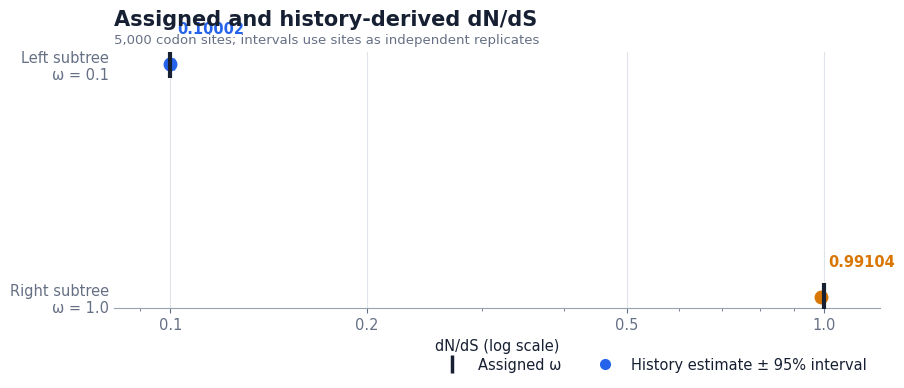

In [5]:
fig, ax = plt.subplots(figsize=(9.2, 4.2))
y_positions = [1, 0]

for y, row in zip(y_positions, summary_rows):
    estimate = row["empirical_dN_dS"]
    target = row["assigned_omega"]
    lower = row["dN_dS_95pct_lower"]
    upper = row["dN_dS_95pct_upper"]
    color = MODE_COLOR[row["mode"]]
    ax.plot([target, estimate], [y, y], color="#98A2B3", lw=1.2, zorder=1)
    ax.errorbar(estimate, y,
                xerr=[[estimate - lower], [upper - estimate]],
                fmt="o", ms=9, color=color, ecolor=color,
                elinewidth=2, capsize=4, zorder=3)
    ax.scatter([target], [y], marker="|", s=420, linewidths=3,
               color=INK, zorder=4)
    ax.text(estimate * 1.025, y + 0.13, f"{estimate:.5f}",
            color=color, fontsize=10.5, fontweight="semibold")

ax.set_xscale("log")
ax.set_xlim(0.082, 1.22)
ax.set_xticks([0.1, 0.2, 0.5, 1.0])
ax.get_xaxis().set_major_formatter(mpl.ticker.ScalarFormatter())
ax.set_yticks(y_positions, ["Left subtree\nω = 0.1", "Right subtree\nω = 1.0"])
ax.set_xlabel("dN/dS (log scale)")
ax.set_title("Assigned and history-derived dN/dS", loc="left", pad=19)
ax.text(0, 1.02, "5,000 codon sites; intervals use sites as independent replicates",
        transform=ax.transAxes, color=MUTED, fontsize=9.5, va="bottom")
ax.grid(axis="x", color=GRID, lw=0.8, alpha=0.8)
ax.spines[["top", "right", "left"]].set_visible(False)
ax.tick_params(axis="y", length=0)
legend = [
    Line2D([0], [0], marker="|", color="none", markeredgecolor=INK,
           markeredgewidth=2.5, markersize=13, label="Assigned ω"),
    Line2D([0], [0], marker="o", color="none", markerfacecolor=BLUE,
           markeredgecolor=BLUE, markersize=7, label="History estimate ± 95% interval"),
]
ax.legend(handles=legend, frameon=False, loc="lower right", ncol=2,
          bbox_to_anchor=(1, -0.3))
fig.tight_layout()
fig.savefig(FIGURE_DIR / "gy94_history_calibration.png")
fig.savefig(FIGURE_DIR / "gy94_history_calibration.svg")
plt.show()

The $\omega=0.1$ estimate differs from its target by only +0.022%. The
$\omega=1$ estimate is 0.896% below its target. With 5,000 independent sites,
the interval is narrow enough that this particular fixed-seed value lies below
1; the practical discrepancy remains less than one percent. The purpose of
this check is to detect a material generator or scaling failure, not to require
one Monte Carlo realization to equal its parameter exactly.

### A complete substitution history on the tree

PalantiR retains event times and state changes, not only the alignment at the
tips. The next figure selects one site objectively: the site whose four counts
(synonymous and nonsynonymous events in each subtree) are jointly closest to
their across-site medians. Every event for that site is then placed on its
actual branch and at its recorded time.

In [6]:
@dataclass
class TreeNode:
    index: int
    label: str = ""
    length: float = 0.0
    children: list = field(default_factory=list)
    parent: object = None
    depth: float = 0.0
    y: float = 0.0


class NewickParser:
    '''Small parser sufficient for PalantiR's plain branch-length trees.'''
    def __init__(self, text):
        self.text = text.strip()
        self.position = 0
        self.next_index = 0

    def _node(self):
        node = TreeNode(self.next_index)
        self.next_index += 1
        if self.text[self.position] == "(":
            self.position += 1
            while True:
                child = self._node()
                child.parent = node
                node.children.append(child)
                if self.text[self.position] == ",":
                    self.position += 1
                    continue
                assert self.text[self.position] == ")"
                self.position += 1
                break
        node.label = self._token()
        if self.position < len(self.text) and self.text[self.position] == ":":
            self.position += 1
            node.length = float(self._token())
        return node

    def _token(self):
        start = self.position
        while self.position < len(self.text) and self.text[self.position] not in ":,();":
            self.position += 1
        return self.text[start:self.position].strip()

    def parse(self):
        root = self._node()
        if self.position < len(self.text) and self.text[self.position] == ";":
            self.position += 1
        assert self.position == len(self.text)
        return root


tree_text = (ARTIFACT / "tree_50_taxa_depth20.newick").read_text().strip()
tree_root = NewickParser(tree_text).parse()
nodes = {}
leaf_order = []

def assign_layout(node, depth=0.0):
    node.depth = depth
    nodes[node.index] = node
    if not node.children:
        node.y = len(leaf_order)
        leaf_order.append(node)
    else:
        for child in node.children:
            assign_layout(child, depth + child.length)
        node.y = float(np.mean([child.y for child in node.children]))

assign_layout(tree_root)

branch_by_node = {row["node"]: row for row in branch_rows}
assert len(leaf_order) == 50
assert set(branch_by_node) == set(range(1, 99))
assert np.allclose([leaf.depth for leaf in leaf_order], 20.0)
assert all(math.isclose(nodes[index].length, row["branch_length"], abs_tol=1e-12)
           for index, row in branch_by_node.items())

# Choose a site close to all four medians, with scale-standardized distances.
features = np.vstack([
    synonymous_by_site[0], nonsynonymous_by_site[0],
    synonymous_by_site[1], nonsynonymous_by_site[1],
]).T
medians = np.median(features, axis=0)
scales = np.std(features, axis=0, ddof=1)
representative_site = int(np.argmin(np.sum(np.abs(features - medians) / scales, axis=1)))

site_events = []
with gzip.open(ARTIFACT / "substitution_history.tsv.gz", "rt", newline="") as handle:
    reader = csv.DictReader(handle, delimiter="\t")
    for event in reader:
        if int(event["site"]) == representative_site:
            site_events.append({
                "node": int(float(event["node"])),
                "time": float(event["time"]),
                "synonymous": event["synonymous"].upper() == "TRUE",
                "mode": int(float(event["mode"])),
                "codon_from": event["codon_from"],
                "codon_to": event["codon_to"],
            })

representative_counts = features[representative_site]
print(f"Representative site: {representative_site} (PalantiR sites are zero-based)")
print("Counts [left S, left N, right S, right N]:", representative_counts.tolist())
print("Total recorded events at this site:", len(site_events))

Representative site: 512 (PalantiR sites are zero-based)
Counts [left S, left N, right S, right N]: [36, 8, 34, 77]
Total recorded events at this site: 155


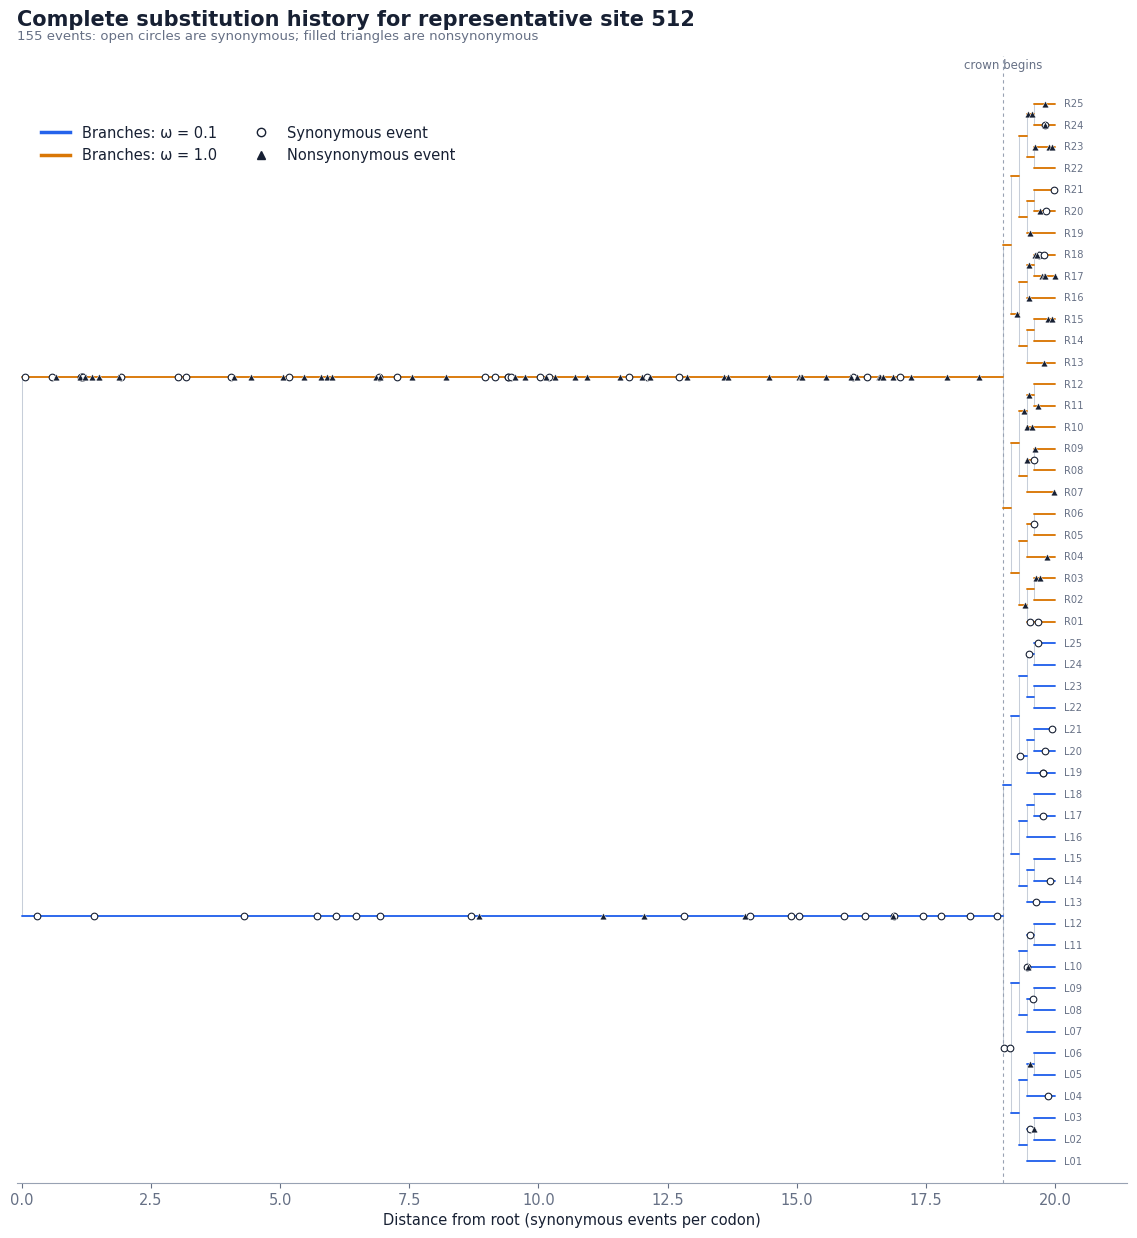

In [7]:
fig, ax = plt.subplots(figsize=(11.5, 12.5))

# Conventional rectangular phylogram: neutral vertical connectors, mode-colored branches.
for node in nodes.values():
    if node.children:
        ax.plot([node.depth, node.depth],
                [min(child.y for child in node.children), max(child.y for child in node.children)],
                color="#C7CED9", lw=0.75, zorder=0)
for node in nodes.values():
    if node.parent is None:
        continue
    mode = branch_by_node[node.index]["state"]
    ax.plot([node.parent.depth, node.depth], [node.y, node.y],
            color=MODE_COLOR[mode], lw=1.35, solid_capstyle="round", zorder=1)

syn_x, syn_y, nonsyn_x, nonsyn_y = [], [], [], []
for event in site_events:
    node = nodes[event["node"]]
    x = node.parent.depth + event["time"]
    if event["synonymous"]:
        syn_x.append(x); syn_y.append(node.y)
    else:
        nonsyn_x.append(x); nonsyn_y.append(node.y)

ax.scatter(syn_x, syn_y, s=23, facecolors="white", edgecolors=INK,
           linewidths=0.8, marker="o", zorder=3)
ax.scatter(nonsyn_x, nonsyn_y, s=24, facecolors=INK, edgecolors="white",
           linewidths=0.35, marker="^", zorder=4)

for leaf in leaf_order:
    ax.text(20.18, leaf.y, leaf.label, va="center", fontsize=7.1, color=MUTED)

ax.axvline(19, color="#98A2B3", lw=0.8, ls=(0, (3, 3)), zorder=0)
ax.text(19, 50.5, "crown begins", ha="center", va="bottom", fontsize=8.5, color=MUTED)
ax.set_xlim(-0.1, 21.4)
ax.set_ylim(-1, 51.2)
ax.set_yticks([])
ax.set_xlabel("Distance from root (synonymous events per codon)")
ax.set_title(f"Complete substitution history for representative site {representative_site}",
             loc="left", pad=22)
ax.text(0, 1.012,
        f"{len(site_events)} events: open circles are synonymous; filled triangles are nonsynonymous",
        transform=ax.transAxes, color=MUTED, fontsize=9.5, va="bottom")
ax.spines[["top", "right", "left"]].set_visible(False)
ax.tick_params(axis="y", length=0)

legend = [
    Line2D([0], [0], color=BLUE, lw=2.5, label="Branches: ω = 0.1"),
    Line2D([0], [0], color=GOLD, lw=2.5, label="Branches: ω = 1.0"),
    Line2D([0], [0], marker="o", color="none", markerfacecolor="white",
           markeredgecolor=INK, markersize=6, label="Synonymous event"),
    Line2D([0], [0], marker="^", color="none", markerfacecolor=INK,
           markeredgecolor=INK, markersize=6, label="Nonsynonymous event"),
]
ax.legend(handles=legend, frameon=False, ncol=2, loc="upper left",
          bbox_to_anchor=(0.01, 0.95))
fig.tight_layout()
fig.savefig(FIGURE_DIR / "gy94_representative_site_history.png")
fig.savefig(FIGURE_DIR / "gy94_representative_site_history.svg")
plt.show()

The two subtrees have similar synonymous opportunity and branch exposure, so
the synonymous event burden remains comparable. The neutral subtree contains
many more amino-acid-changing events, exactly as expected from its tenfold
higher $\omega$. Because the histories retain codon changes and event times,
the same object can support much more detailed checks than an endpoint
alignment alone.

### Across-site event counts

Each point below is one codon site summarized across all 49 branches in one
subtree. Crosses show stationary expectations calculated from the exact rate
matrices and the total branch exposure. This view preserves the 5,000-site
sampling variation instead of showing only aggregate totals.

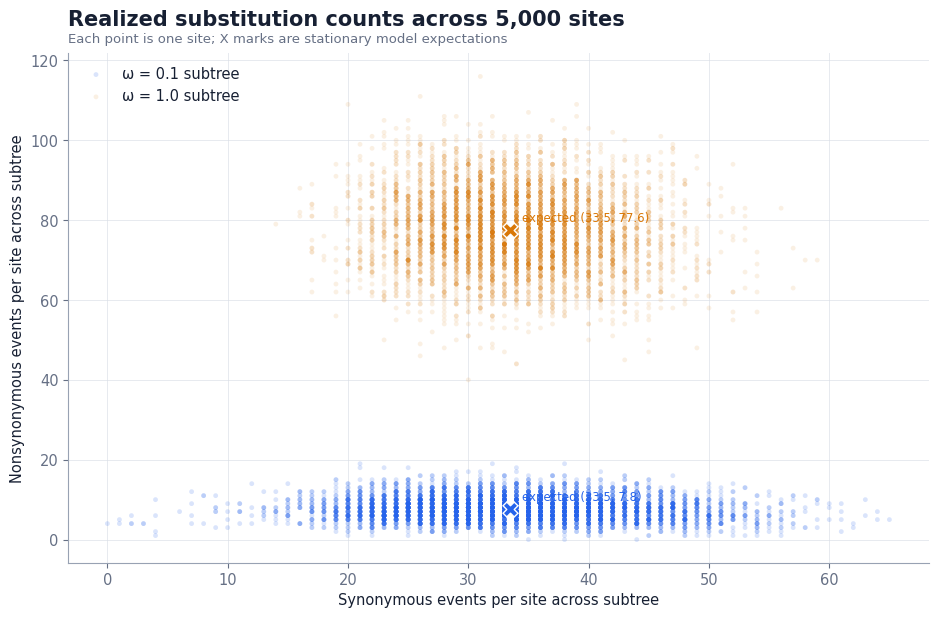

In [8]:
fig, ax = plt.subplots(figsize=(9.5, 6.3))

for mode, label in [(0, "ω = 0.1 subtree"), (1, "ω = 1.0 subtree")]:
    ax.scatter(synonymous_by_site[mode], nonsynonymous_by_site[mode],
               s=12, alpha=0.17 if mode == 0 else 0.11,
               color=MODE_COLOR[mode], edgecolors="none", rasterized=True,
               label=label)
    branch_length = summary_rows[mode]["total_branch_length"]
    expected_syn = branch_length * matrix_rate_rows[mode]["synonymous_rate"]
    expected_nonsyn = branch_length * matrix_rate_rows[mode]["nonsynonymous_rate"]
    ax.scatter([expected_syn], [expected_nonsyn], marker="X", s=115,
               color=MODE_COLOR[mode], edgecolors="white", linewidths=1.0, zorder=5)
    ax.annotate(f"expected ({expected_syn:.1f}, {expected_nonsyn:.1f})",
                (expected_syn, expected_nonsyn), xytext=(8, 6),
                textcoords="offset points", fontsize=8.5, color=MODE_COLOR[mode])

ax.set_xlabel("Synonymous events per site across subtree")
ax.set_ylabel("Nonsynonymous events per site across subtree")
ax.set_title("Realized substitution counts across 5,000 sites", loc="left", pad=20)
ax.text(0, 1.015, "Each point is one site; X marks are stationary model expectations",
        transform=ax.transAxes, color=MUTED, fontsize=9.5, va="bottom")
ax.grid(color=GRID, lw=0.7, alpha=0.65)
ax.set_axisbelow(True)
ax.spines[["top", "right"]].set_visible(False)
ax.legend(frameon=False, loc="upper left")
fig.tight_layout()
fig.savefig(FIGURE_DIR / "gy94_per_site_event_counts.png")
fig.savefig(FIGURE_DIR / "gy94_per_site_event_counts.svg")
plt.show()

## Reproducing the simulation with PalantiR

The complete production driver is
[`validation/gy94_deep_tree_history_dnds.R`](https://github.com/dekoning-lab/PalantiR/blob/master/validation/gy94_deep_tree_history_dnds.R).
From the repository root:

```bash
Rscript validation/gy94_deep_tree_history_dnds.R \
  --sites=5000 \
  --seed=20260825 \
  --out=runs/gy94-deep-tree-dnds-20260825
```

The core model construction follows the public GY94 interface:

```r
use_genetic_code("Standard nuclear")

pi <- F1x4(c(T = 0.22, C = 0.28, A = 0.27, G = 0.23))
models <- list(
  GY94(omega = 0.1, kappa = 4, frequencies = pi,
       scaling_type = "synonymous-per-codon"),
  GY94(omega = 1.0, kappa = 4, frequencies = pi,
       scaling_type = "synonymous-per-codon")
)

branch_process <- GY94BranchModel(
  models = models,
  mode_phylogeny = mode_tree,
  start_mode = 0L
)
site_model <- GY94SiteModel(
  list(branch_process = branch_process),
  n_sites = 5000
)

set_palantir_seed(20260825)
simulation <- simulate_gy94_site_model(tree, site_model)
head(simulation$substitutions)
```

The driver additionally writes the tree, mode tree, alignment, compressed
history, per-site counts, opportunity calculation, model rates, compact R
objects, run metadata, and an MD5 manifest.

## Takeaways

1. **Branch assignment works.** All 49 branches in each major subtree use the
   intended GY94 process, and the history contains the expected large
   difference in nonsynonymous flux.
2. **Synonymous-per-codon scaling retains its meaning.** The empirical synonymous rates
   were 1.00032 and 1.00756 events per codon-branch unit, close to their exact
   stationary target of 1.
3. **The history recovers $\omega$.** Opportunity-normalized estimates were
   0.10002 and 0.99104 for assigned values 0.1 and 1.0.
4. **Raw N/S is not $d_N/d_S$.** Correct interpretation requires the neutral
   synonymous and nonsynonymous opportunity counts implied by the genetic code,
   codon frequencies, and $\kappa$.
5. **Complete histories are a useful validation surface.** They expose event
   timing, state changes, branch identity, and site-level variation that cannot
   be recovered from the endpoint alignment.

<div class="scope-note">
<strong>Scope:</strong> this is a simple stationary-frequency, single-site-class
GY94 demonstration. It validates this generator, branch heterogeneity, history
recording, and synonymous-per-codon scaling. It is not by itself a validation of every
site-mixture, branch-site, transient-frequency, or inference configuration.
</div>

### References

* Goldman N, Yang Z. 1994. A codon-based model of nucleotide substitution for
  protein-coding DNA sequences. *Molecular Biology and Evolution* 11:725–736.
  [doi:10.1093/oxfordjournals.molbev.a040153](https://doi.org/10.1093/oxfordjournals.molbev.a040153)
* Yang Z. PAML source implementation, `eigenQcodon()` in
  [`codeml.c`](https://github.com/abacus-gene/paml/blob/master/src/codeml.c).
* PalantiR production artifact generated 2026-08-25 with package version 1.3.0;
  local provenance is retained in
  `runs/gy94-deep-tree-dnds-20260825/run_info.txt`.